In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
from scipy.stats import gaussian_kde
from datetime import datetime

## SNP histograms

#### For one pat

load df

In [2]:
pat='RBH_12'
df_pat=pd.read_csv(f'{pat}/mut_dyn/mut_evolution_dates.txt',sep='\t')
df_pat['date']=pd.to_datetime(df_pat['date'],format='%d-%m-%Y')
df_pat.sort_values('date',inplace=True)
df_pat.head()

ValueError: time data "Nodate" doesn't match format "%d-%m-%Y", at position 7. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

we want to view the distribution of snp that are not shared throughout the popiulation to cluster into subpopulations. We try to remove snp that are fixed in the population by removing those that are never bellow 90% during good quality calls (replace with binomial stats at 5%??).

In [ ]:
# get series of fixed snp. Index pos and value True if fixed
df_gcalls=df_pat[df_pat['passed_filter']==True]
fixed_series=df_gcalls.groupby('position').min()['allele_freq']>=0.9
# filter dataframe to remove fixed snp
fixed_positions=fixed_series[fixed_series].index
df_pat=df_pat[~df_pat['position'].isin(fixed_positions)]
df_pat


,position,depth,ref,alt,DP4,allele_freq,PV4,lane,passed_filter,date
800040,4165062,155,A,.,"61,35,0,0",0.000000,NaN,50416_2#8,False,2016-01-30
800039,4164994,133,G,C,"0,0,51,34",1.000000,NaN,50416_2#8,False,2016-01-30
800037,4164342,129,G,C,"0,0,52,28",1.000000,NaN,50416_2#8,False,2016-01-30
800036,4164337,125,G,A,"1,1,52,25",0.974684,NaN,50416_2#8,False,2016-01-30
800034,4163747,143,C,A,"0,1,58,37",0.989583,NaN,50416_2#8,True,2016-01-30
...,...,...,...,...,...,...,...,...,...,...
2104292,2067563,110,A,G,"1,0,26,41",0.985294,NaN,50926_1#18,False,2017-03-05
2104302,2078517,93,G,.,"31,28,0,0",0.000000,NaN,50926_1#18,False,2017-03-05
2104299,2078112,116,A,G,"1,0,46,30",0.987013,NaN,50926_1#18,False,2017-03-05
2104301,2078348,109,C,.,"33,40,0,0",0.000000,NaN,50926_1#18,False,2017-03-05


remove snp were at 0 freq. If snp only at few time points might be error or contamination. 

In [ ]:
df_pat=df_pat[df_pat['allele_freq']>0]

Load and clean database function

In [6]:
def load_pat(pat):
    def is_valid_date(date_str): # check if date is valid
        try:
            datetime.strptime(date_str, "%d-%m-%Y")
            return True
        except ValueError:
            return False
    # load df
    df_pat=pd.read_csv(f'{pat}/mut_dyn/mut_evolution_dates.txt',sep='\t')
    df_pat=df_pat[df_pat['date'].map(is_valid_date)] # filter invalid dates
    df_pat['date']=pd.to_datetime(df_pat['date'],format='%d-%m-%Y')
    df_pat.sort_values('date',inplace=True)

    # get series of fixed snp. Index pos and value True if fixed
    df_gcalls=df_pat[df_pat['passed_filter']==True]
    fixed_series=df_gcalls.groupby('position').min()['allele_freq']>=0.9
    # filter dataframe to remove fixed snp
    fixed_positions=fixed_series[fixed_series].index
    df_pat=df_pat[~df_pat['position'].isin(fixed_positions)]

    # remove snp were at 0 freq. If snp only at few time points might be error or contamination. 
    df_pat=df_pat[df_pat['allele_freq']>0]

    return df_pat

df_pat=load_pat('Papworth_9')

facet plot with sns

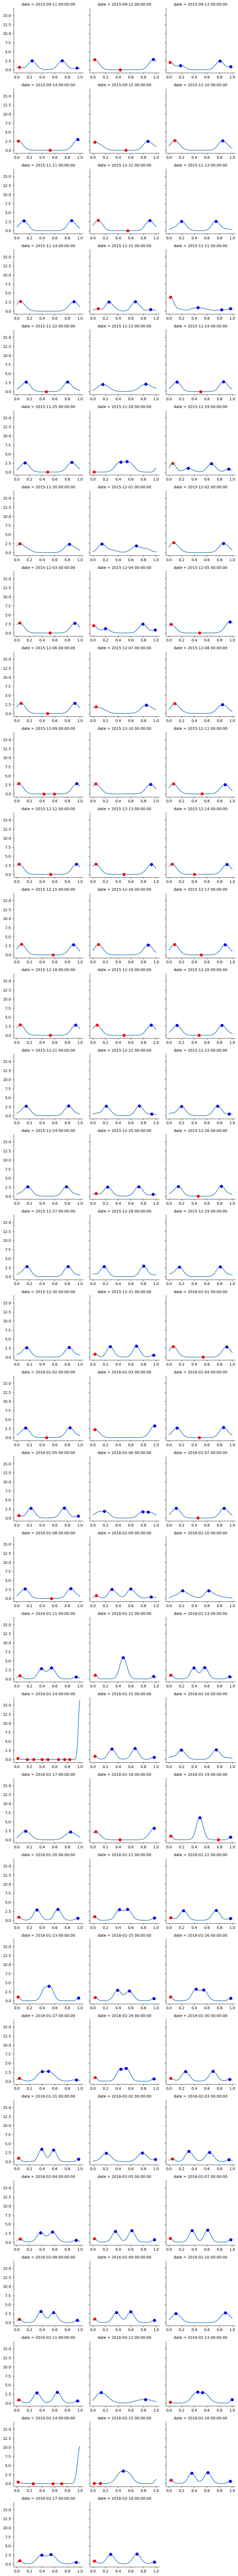

In [10]:
# Function to plot KDE + mark extrema
def kde_with_extrema(data, color=None, threshold=300, width=0.05, min=0.1, fill=False):
    x = np.linspace(0, 1, 500)
    kde = gaussian_kde(data['allele_freq'])
    y = kde(x)

    # Find local minima and maxima
    maxima = argrelextrema(y, np.greater)[0]

    # Plot the KDE curve
    plt.plot(x, y, color=color or "steelblue")

    # Mark local maxima (peaks)
    plt.scatter(x[maxima], y[maxima], color='red', s=50, zorder=5, label="maxima")
    # mark filtered maxima
    fil_max=[]
    for m in maxima:
        count=((data['allele_freq']>(x[m]-width)) & (data['allele_freq']<(x[m]+width))).sum()
        if count>threshold and x[m]>min:
            fil_max.append(m)
    plt.scatter(x[fil_max], y[fil_max], color='blue', s=50, zorder=5, label="maxima filtered")

# assign facets
facets=sns.FacetGrid(df_pat,col='date',col_wrap=3,sharex=False)
# plot histograms
#facets.map(sns.kdeplot,'allele_freq')
#facets.map(sns.histplot,'allele_freq',bins=50)
facets.map_dataframe(kde_with_extrema)

For each patient check maxima kde for each sample and count how many have >300 mutations +- 5% either side

In [ ]:
def check_extrema_pat(pat,threshold=300,width=0.05, min=0.1): 
    def check_extrema_date(data,date,threshold=300,width=0.05):
        current_df=data[data['date']==date]
        x = np.linspace(0, 1, 500)
        kde = gaussian_kde(current_df['allele_freq'])
        y = kde(x)
    
        # Find local minima and maxima
        maxima = argrelextrema(y, np.greater)[0]
        max_x=[]
        peak_strengths=[]
        for m in x[maxima]:
            count=((current_df['allele_freq']>(m-width)) & (current_df['allele_freq']<(m+width))).sum()
            if count>threshold and x[m]>min:
                max_x.append(m)
                peak_strengths.append(count)
        return max_x, peak_strengths

    df_pat=load_pat(pat)

    num_peaks=[]
    for date in df_pat['date'].unique():
        mx, ps=check_extrema_date(df_pat,date,threshold=threshold,width=width)
        num_peaks.append(len(mx))
    
    #plt.hist(num_peaks, bins=range(0, max(num_peaks)+2), align='left')
    #plt.xlabel('Number of peaks per timepoint')
    #plt.ylabel('Frequency')

    return num_peaks

# load pats
with open('all_pats.txt','r') as f:
    pats=[line.strip() for line in f]
    pats.remove('all_pats')

mixed_pats=[]
for pat in pats:
    print(f'Processing {pat}')
    peaks=check_extrema_pat(pat,threshold=300,width=0.05)
    bigger_than_2=sum(n>2 for n in peaks)
    if bigger_than_2>4:
        mixed_pats.append((pat,bigger_than_2))

mixed_pats

    
    

Processing Bristol_14
Processing Bristol_19
Processing Bristol_20
Processing Bristol_5
Processing Bristol_8
Processing FPH_2
Processing FPH_4
Processing FPH_6
Processing FPH_7
Processing FPH_8
Processing FPH_9
Processing KINGS_18
Processing Leeds_1689
Processing Leeds_193
Processing Papworth_1
Processing Papworth_12
Processing Papworth_15
Processing Papworth_17
Processing Papworth_2
Processing Papworth_20
Processing Papworth_21
Processing Papworth_22
Processing Papworth_23
Processing Papworth_24
Processing Papworth_25
Processing Papworth_26
Processing Papworth_27
Processing Papworth_28
Processing Papworth_29
Processing Papworth_3
Processing Papworth_30
Processing Papworth_31
Processing Papworth_32
Processing Papworth_33
Processing Papworth_34
Processing Papworth_35
Processing Papworth_4
Processing Papworth_5
Processing Papworth_7


### Analyse mixed results

load df

total of 838 mixed samples


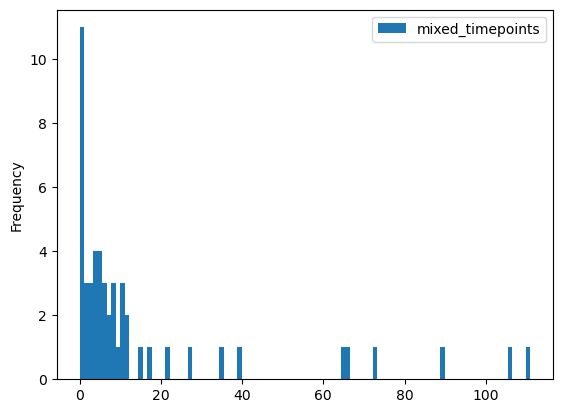

In [ ]:
df_mixed=pd.read_csv('mixed.tsv',sep='\t')
df_mixed.plot(kind='hist',x='pat',y='mixed_timepoints',bins=100)
print(f'total of {df_mixed.mixed_timepoints.sum()} mixed samples')

get samples per pat

In [7]:
with open('all_pats.txt','r') as f:
    pats=[line.strip() for line in f]

pat_samples={}
for pat in pats:
    df_pat=load_pat(pat)
    lanes=df_pat.lane.unique()
    pat_samples[pat]=len(lanes)

    

percentage of mixed timepoints per pat

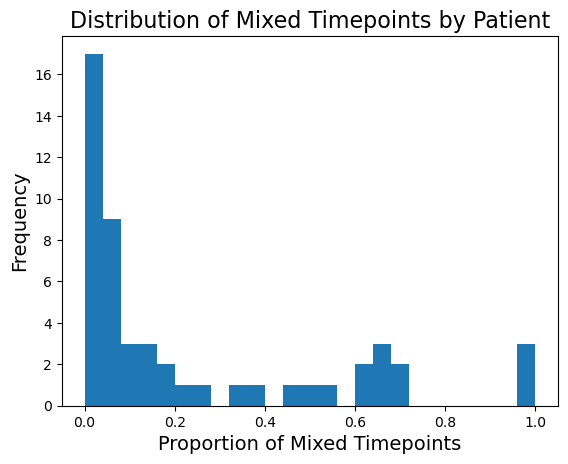

In [8]:
df_mixed['prop']=df_mixed['mixed_timepoints']/df_mixed['pat'].map(pat_samples)
df_mixed.plot(kind='hist',x='pat',y='prop',bins=25)
plt.title('Distribution of Mixed Timepoints by Patient',fontsize=16)
plt.xlabel('Proportion of Mixed Timepoints',fontsize=14)
plt.ylabel('Frequency',fontsize=14)
plt.legend().remove()

Output mixed pats

In [13]:
mixed_pats=df_mixed[df_mixed['prop']>0.1].pat.tolist()
with open('mixed_pats.txt','w') as f:
    for pat in mixed_pats:
        f.write(f'{pat}\n')

Output clonal pats

In [19]:
clonal_pats=df_mixed[~(df_mixed['pat'].isin(mixed_pats))].pat.to_list()
with open('clonal_pats.txt','w') as f:
    for pat in clonal_pats:
        f.write(f'{pat}\n')

Get number of dis